In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import seaborn as sns
import cartopy.crs as ccrs
import geopandas as gpd
import cartopy.feature as cfeature
import cartopy
import os
import math

In [4]:
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)


In [ ]:

filepath = '/nesi/project/niwa00015/queenle/data/flows/daily/40plus/'

df_list = []

for filename in os.listdir(filepath):
    
    if filename == 'full_records.csv':
        continue

    header = open(filepath + filename).readline().strip().split(' ')
    site_number = header[1]
    site_name = " ".join(header[2:])
    
    site_df = pd.read_csv(filepath + filename, header=1)
    site_df.Date = pd.to_datetime(site_df.Date)
    site_df.set_index('Date', inplace=True)
    site_df.columns = ['time','flow']
    site_df = site_df.replace('gap ', math.nan)
    site_df["flow"] = pd.to_numeric(site_df["flow"])
        
    replace_dates = {}
    for date in site_df.index:
        if date.year > 2020:
            new_date = date.replace(year=date.year - 100)
            replace_dates[date] = new_date
            
    site_df.rename(replace_dates,inplace=True)
    site_df = site_df.drop(columns=['time'])
 
    site_df.columns = [site_number]
    
    df_list.append(site_df)
    
daily_flow_df = pd.concat(df_list,axis=1)


In [ ]:
# dropping this location because the catchment areas recorded in the arcgis shape file and the metadata 
# are significantly different
daily_flow_df = daily_flow_df.drop(columns=['78637'])

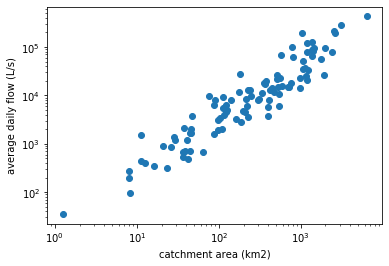

In [4]:
areas = []
vals = []
for site in daily_flow_df:

    catch_area = float(metadata_df['area_km2'].loc[float(site)])
    average_daily_flow = float(daily_flow_df[site].mean())
    
    areas.append(catch_area)
    vals.append(average_daily_flow)
    
plt.scatter(areas,vals)
plt.xlabel('catchment area (km2)')
plt.ylabel('average daily flow (L/s)')
plt.xscale('log')
plt.yscale('log')

In [2]:
seasonal_flow_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/flows/seasonal/40_50yrs/40plus.csv")
seasonal_flow_df.date = pd.to_datetime(seasonal_flow_df.date)
seasonal_flow_df.set_index('date', inplace=True)

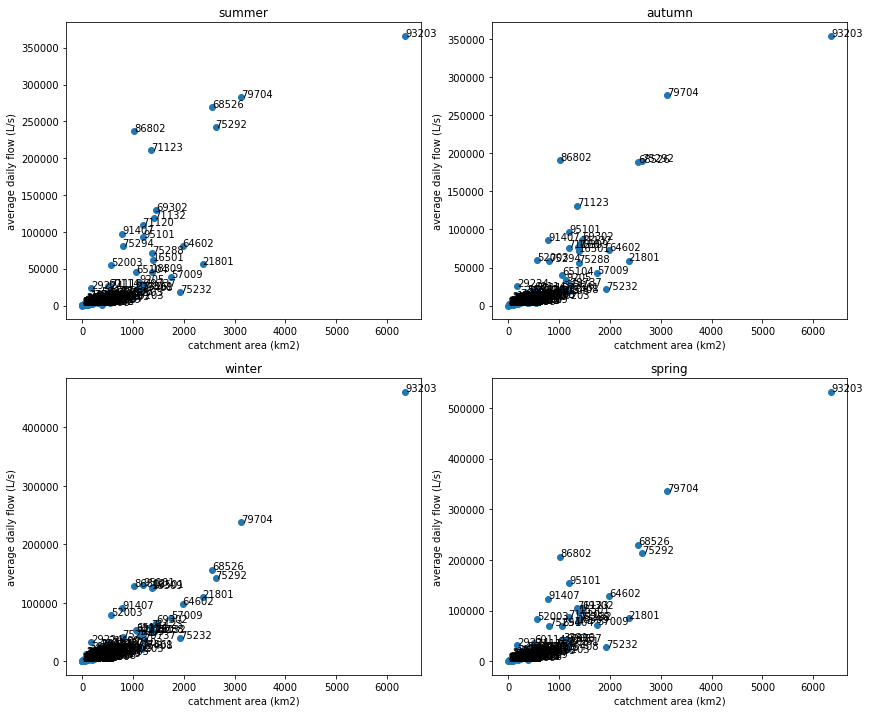

In [21]:
fig,axs = plt.subplots(2,2,figsize=(14,12))
axs = axs.flatten()
seasons = [12,3,6,9]
titles = ['summer','autumn','winter','spring']
for i in range(len(axs)):
    season_flow_df = seasonal_flow_df[seasonal_flow_df.index.month.isin([seasons[i]])]

    areas = []
    vals = []
    labels = []
    for site in season_flow_df:

        catch_area = float(metadata_df['area_km2'].loc[float(site)])
        average_seasonal_flow = float(season_flow_df[site].mean())

        areas.append(catch_area)
        vals.append(average_seasonal_flow)
        axs[i].text(catch_area,average_seasonal_flow,site)

    
    axs[i].scatter(areas,vals)
    axs[i].set_xlabel('catchment area (km2)')
    axs[i].set_ylabel('average daily flow (L/s)')
    #axs[i].set_xscale('log')
    #axs[i].set_yscale('log')
    axs[i].set_title(titles[i])
    


In [14]:
high = [86802,71123,75292,68526,79704]

low = [75232,21801]

In [17]:
for site in high:
    print(str(site) + ": " + metadata_df['Name'].loc[site])

86802: Haast at Roaring Billy
71123: Lake Pukaki at Canal Inlet Gate
75292: Lake Wanaka at Roys Bay
68526: Rakaia at Fighting Hill
79704: Lake Te Anau at Park HQ


In [18]:
for site in low:
    print(str(site) + ": " + metadata_df['Name'].loc[site])

75232: Pomahaka at Burkes Ford
21801: Mohaka at Raupunga
